In [4]:
import pandas as pd

# Load and prepare data
weather_df = pd.read_csv('weatherAUS.csv')

# Prophet requires columns named 'ds' (date) and 'y' (target)
# Let's predict MaxTemp for a specific location
df = weather_df[weather_df['Location'] == 'Sydney'].copy()
df = df[['Date', 'MaxTemp']].dropna()
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])

In [6]:
from prophet import Prophet

# Train Prophet model (very automated - handles seasonality, trends, holidays)
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.fit(df)

23:48:41 - cmdstanpy - INFO - Chain [1] start processing
23:48:41 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# Make future predictions
future = model.make_future_dataframe(periods=60)  # 60 days ahead
forecast = model.predict(future)

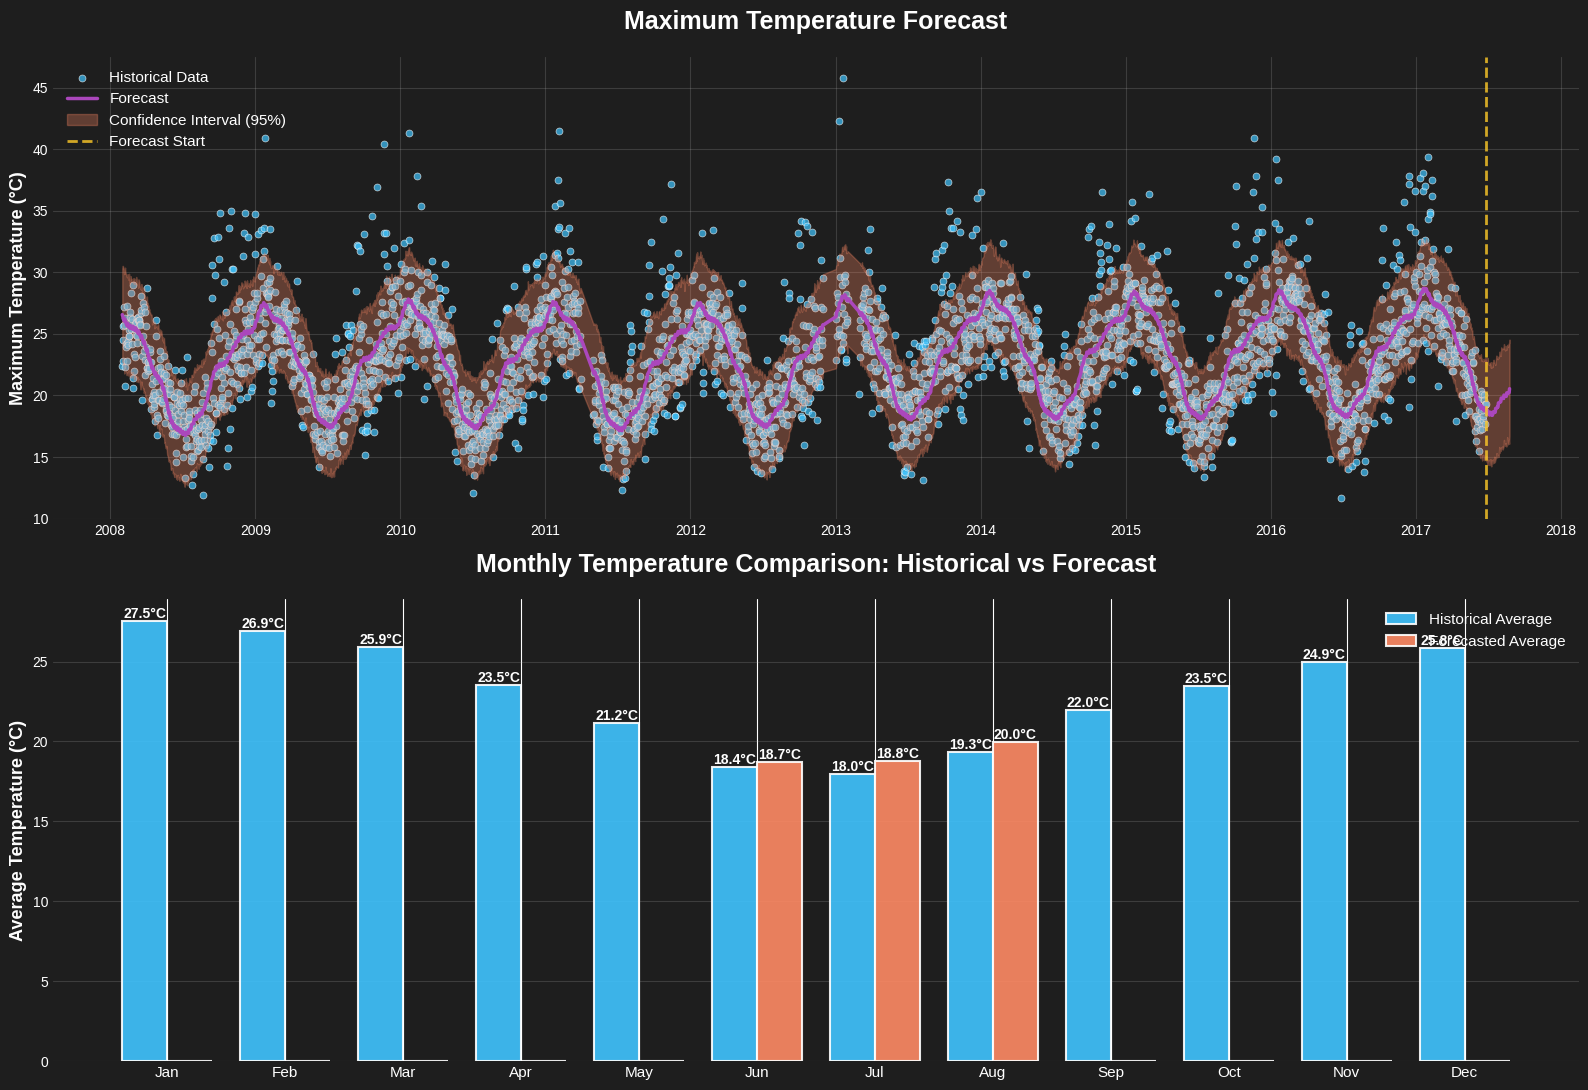

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Set dark theme
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 1, figsize=(16, 11))

# Vibrant color palette for dark theme
colors = {
    'historical': '#40C4FF',  # Bright cyan
    'forecast': '#AB47BC',    # Electric purple
    'confidence': '#FF8A65',  # Soft peach
    'line': '#FFCA28'         # Bright yellow
}

# Plot 1: Main forecast
ax1 = axes[0]
ax1.scatter(df['ds'], df['y'], s=25, alpha=0.7, color=colors['historical'], 
           label='Historical Data', edgecolors='#FFFFFF', linewidth=0.5)
ax1.plot(forecast['ds'], forecast['yhat'], linewidth=2.5, 
         color=colors['forecast'], label='Forecast')
ax1.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                 alpha=0.3, color=colors['confidence'], label='Confidence Interval (95%)')
ax1.axvline(df['ds'].max(), linestyle='--', linewidth=2, 
            color=colors['line'], alpha=0.8, label='Forecast Start')
ax1.set_ylabel('Maximum Temperature (°C)', fontsize=13, fontweight='bold', color='#FFFFFF')
ax1.set_title('Maximum Temperature Forecast', fontsize=18, fontweight='bold', pad=20, color='#FFFFFF')
ax1.legend(loc='upper left', framealpha=0.9, fontsize=11, facecolor='#333333', edgecolor='#FFFFFF', labelcolor='#FFFFFF')
ax1.grid(True, alpha=0.2, color='#BBBBBB')

# Plot 2: Monthly comparison
ax2 = axes[1]
df_monthly = df.copy()
df_monthly['month'] = df_monthly['ds'].dt.month
monthly_avg = df_monthly.groupby('month')['y'].mean()

forecast_future = forecast[forecast['ds'] > df['ds'].max()].copy()
forecast_future['month'] = forecast_future['ds'].dt.month
forecast_monthly = forecast_future.groupby('month')['yhat'].mean()

months = np.arange(1, 13)
x_pos = np.arange(len(months))
width = 0.38

bars1 = ax2.bar(x_pos - width/2, [monthly_avg.get(m, 0) for m in months], 
                width, label='Historical Average', color=colors['historical'], 
                alpha=0.9, edgecolor='#FFFFFF', linewidth=1.5)
bars2 = ax2.bar(x_pos + width/2, [forecast_monthly.get(m, 0) for m in months], 
                width, label='Forecasted Average', color=colors['confidence'], 
                alpha=0.9, edgecolor='#FFFFFF', linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.1f}°C', ha='center', va='bottom', 
                     fontsize=10, fontweight='bold', color='#FFFFFF')

ax2.set_ylabel('Average Temperature (°C)', fontsize=13, fontweight='bold', color='#FFFFFF')
ax2.set_title('Monthly Temperature Comparison: Historical vs Forecast', 
              fontsize=18, fontweight='bold', pad=20, color='#FFFFFF')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=11, color='#FFFFFF')
ax2.legend(loc='upper right', framealpha=0.9, fontsize=11, facecolor='#333333', edgecolor='#FFFFFF', labelcolor='#FFFFFF')
ax2.grid(True, alpha=0.2, axis='y', color='#BBBBBB')

# Set figure background color
fig.patch.set_facecolor('#1E1E1E')
ax1.set_facecolor('#1E1E1E')
ax2.set_facecolor('#1E1E1E')

plt.tight_layout()
plt.show()

In [32]:
# Summary statistics
print("\n" + "="*60)
print("         FORECAST SUMMARY - NEXT 60 DAYS")
print("="*60)
recent_forecast = forecast.tail(60)
print(f"  Average Temperature:     {recent_forecast['yhat'].mean():.1f}°C")
print(f"  Expected Range:          {recent_forecast['yhat'].min():.1f}°C - {recent_forecast['yhat'].max():.1f}°C")
print(f"  Warmest Day Expected:    {forecast.loc[forecast['yhat'].idxmax(), 'ds'].strftime('%Y-%m-%d')} ({forecast['yhat'].max():.1f}°C)")
print(f"  Coolest Day Expected:    {forecast.loc[forecast['yhat'].idxmin(), 'ds'].strftime('%Y-%m-%d')} ({forecast['yhat'].min():.1f}°C)")
print("="*60)


         FORECAST SUMMARY - NEXT 60 DAYS
  Average Temperature:     19.3°C
  Expected Range:          18.4°C - 20.5°C
  Warmest Day Expected:    2017-01-19 (28.7°C)
  Coolest Day Expected:    2008-07-09 (16.7°C)


In [ ]:
from autogluon.tabular import TabularPredictor

# Remove rows with missing target variable
weather_clean = weather_df.dropna(subset=['RainTomorrow']).copy()

print(f"Original rows: {len(weather_df)}")
print(f"After cleaning: {len(weather_clean)}")

# Split data (80/20)
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(weather_clean, test_size=0.2, random_state=42)

# Train AutoGluon
predictor = TabularPredictor(
    label='RainTomorrow',
    eval_metric='accuracy',
    path='./rain_models'
).fit(train_data, time_limit=600, presets='medium')

# Get predictions and probabilities
predictions = predictor.predict(test_data)
pred_probs = predictor.predict_proba(test_data)

# Get feature importance
feature_importance = predictor.feature_importance(test_data)

Preset alias specified: 'medium' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Fri Sep 19 17:47:18 UTC 2025
CPU Count:          12
Memory Avail:       8.78 GB / 15.52 GB (56.6%)
Disk Space Avail:   232.54 GB / 456.39 GB (51.0%)
Presets specified: ['medium']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/home/n/Documents/projects/Freelance/Rain in Australia/rain_models"
Train Data Rows:    113754
Train Data Columns: 22
Label Column:       RainTomorrow
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['No', 'Yes']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter 

Original rows: 145460
After cleaning: 142193


Selected class <--> label mapping:  class 1 = Yes, class 0 = No
	Note: For your binary classification, AutoGluon arbitrarily selected which label-value represents positive (Yes) vs negative (No) class.
	To explicitly set the positive_class, either rename classes to 1 and 0, or specify positive_class in Predictor init.
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    8987.22 MB
	Train Data (Original)  Memory Usage: 48.40 MB (0.5% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeatureGenerator...
		Fitting DatetimeFeatureGenerator...
	Stage 4 Generators:
		F

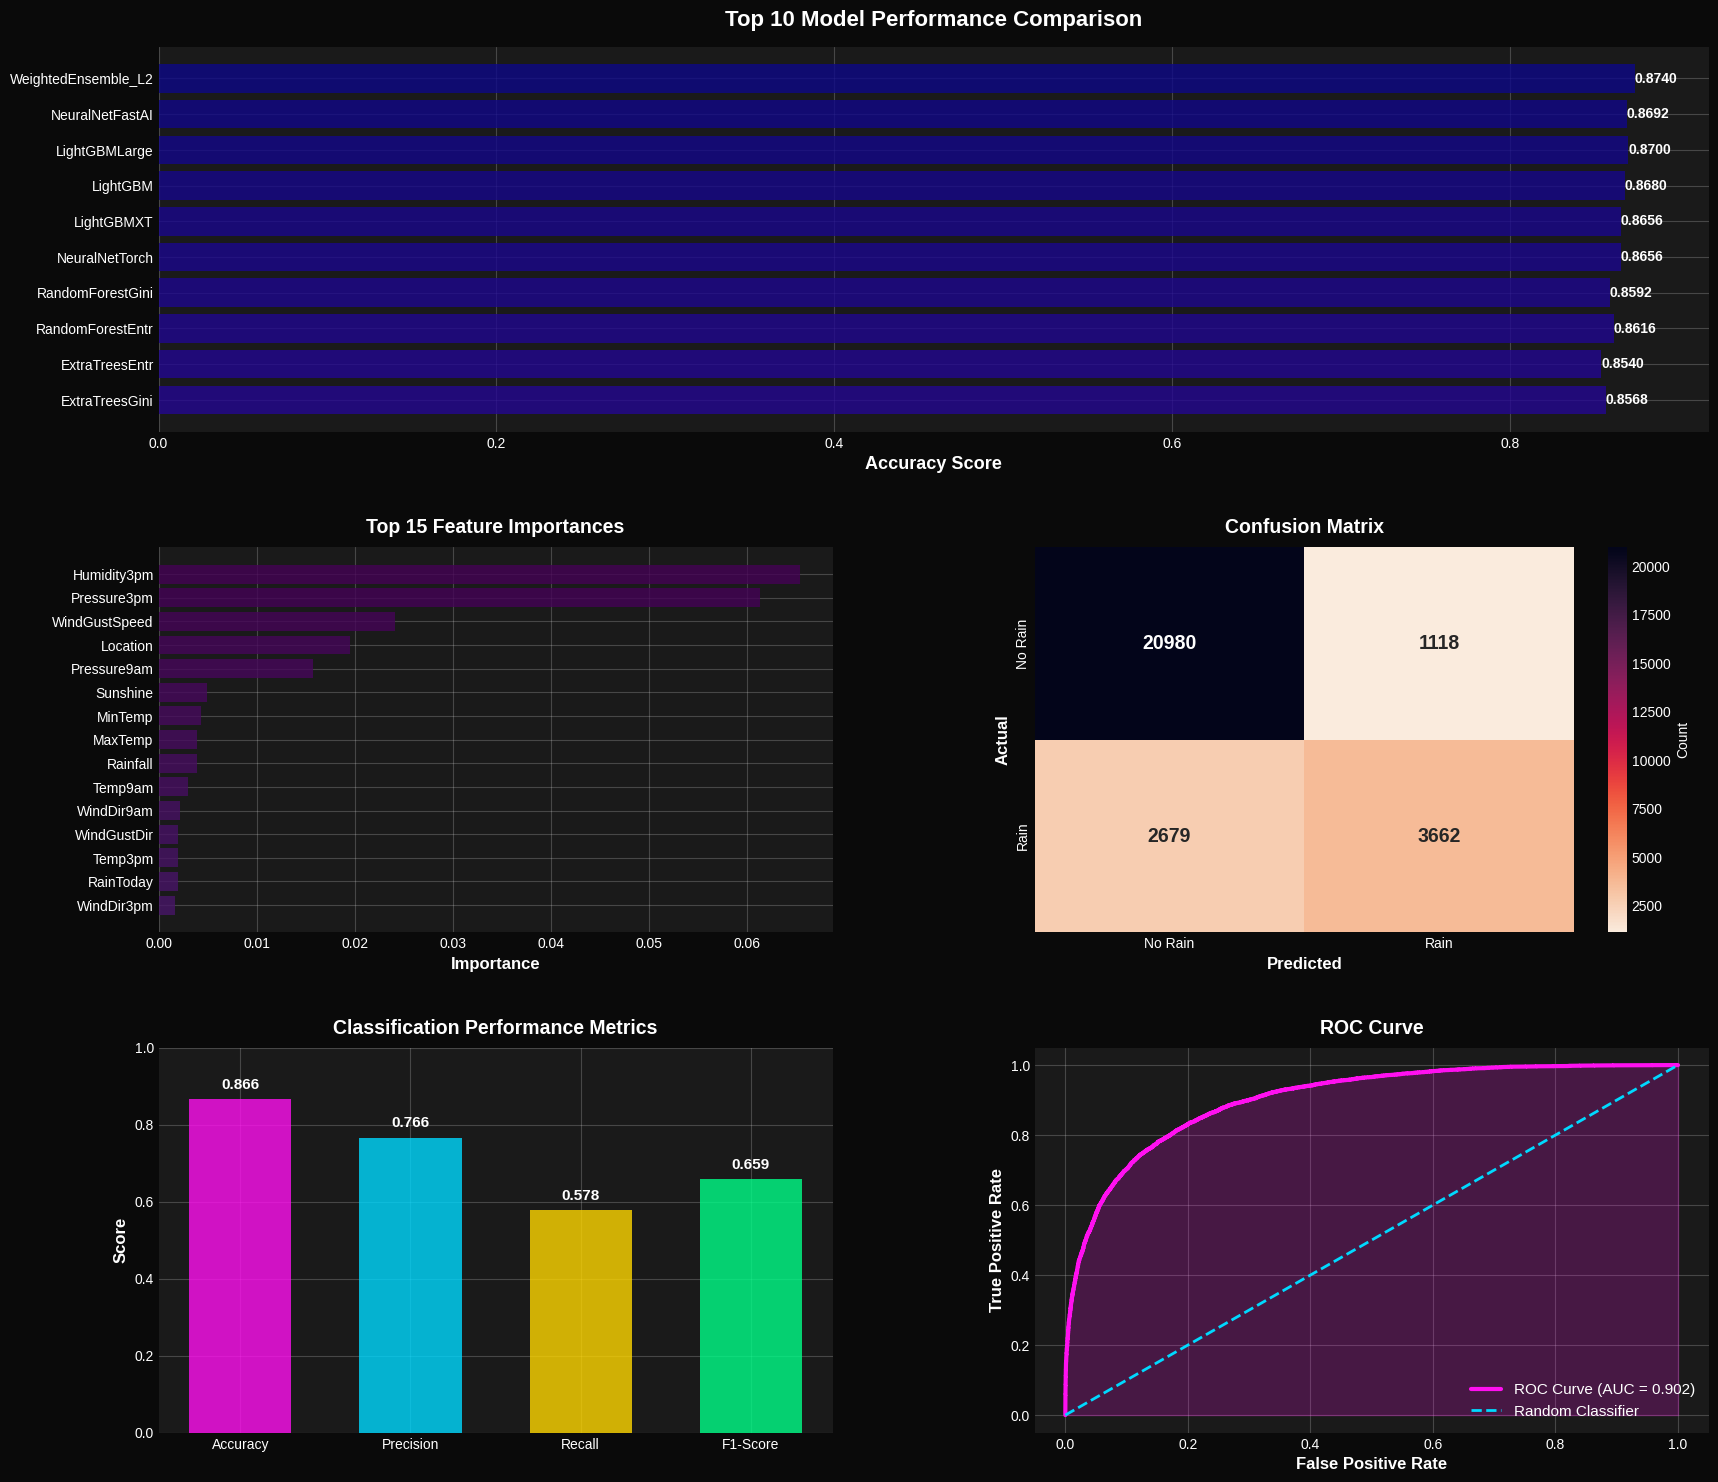

In [73]:
# ============ VISUALIZATIONS ============
plt.style.use('dark_background')
fig = plt.figure(figsize=(20, 18), facecolor='#0a0a0a')

# Create grid
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Model Leaderboard
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#1a1a1a')

leaderboard = predictor.leaderboard(test_data, silent=True)
top_models = leaderboard.head(10)

colors = plt.cm.plasma(range(len(top_models)))
bars = ax1.barh(range(len(top_models)), top_models['score_val'], color=colors, alpha=0.8)
ax1.set_yticks(range(len(top_models)))
ax1.set_yticklabels(top_models['model'], fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('Accuracy Score', fontsize=13, fontweight='bold', color='white')
ax1.set_title('Top 10 Model Performance Comparison', fontsize=16, fontweight='bold', color='white', pad=15)
ax1.grid(True, alpha=0.2)

# Add value labels
for i, (bar, score) in enumerate(zip(bars, top_models['score_val'])):
    ax1.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
            f'{score:.4f}', va='center', ha='left', fontsize=10, 
            color='white', fontweight='bold')

# 2. Feature Importance (FIXED)
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#1a1a1a')

top_features = feature_importance.head(15)
colors_feat = plt.cm.viridis(range(len(top_features)))
bars2 = ax2.barh(range(len(top_features)), top_features['importance'], color=colors_feat, alpha=0.8)
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_features.index, fontsize=10)  # Changed from top_features['feature']
ax2.invert_yaxis()
ax2.set_xlabel('Importance', fontsize=12, fontweight='bold', color='white')
ax2.set_title('Top 15 Feature Importances', fontsize=14, fontweight='bold', color='white', pad=10)
ax2.grid(True, alpha=0.2)

# 3. Confusion Matrix
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#1a1a1a')

from sklearn.metrics import confusion_matrix
y_true = test_data['RainTomorrow']
cm = confusion_matrix(y_true, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r', 
           xticklabels=['No Rain', 'Rain'], 
           yticklabels=['No Rain', 'Rain'],
           cbar_kws={'label': 'Count'}, ax=ax3, 
           annot_kws={'size': 14, 'weight': 'bold'})
ax3.set_xlabel('Predicted', fontsize=12, fontweight='bold', color='white')
ax3.set_ylabel('Actual', fontsize=12, fontweight='bold', color='white')
ax3.set_title('Confusion Matrix', fontsize=14, fontweight='bold', color='white', pad=10)

# 4. Classification Metrics
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor('#1a1a1a')

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
metrics = {
    'Accuracy': accuracy_score(y_true, predictions),
    'Precision': precision_score(y_true, predictions, pos_label='Yes'),
    'Recall': recall_score(y_true, predictions, pos_label='Yes'),
    'F1-Score': f1_score(y_true, predictions, pos_label='Yes')
}

colors_metric = ['#FF10F0', '#00D9FF', '#FFD700', '#00FF88']
bars3 = ax4.bar(metrics.keys(), metrics.values(), color=colors_metric, alpha=0.8, width=0.6)
ax4.set_ylabel('Score', fontsize=12, fontweight='bold', color='white')
ax4.set_title('Classification Performance Metrics', fontsize=14, fontweight='bold', color='white', pad=10)
ax4.set_ylim([0, 1])
ax4.grid(True, alpha=0.2)

# Add value labels
for bar, (name, value) in zip(bars3, metrics.items()):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{value:.3f}', ha='center', va='bottom', fontsize=11,
            color='white', fontweight='bold')

# 5. ROC Curve
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor('#1a1a1a')

from sklearn.metrics import roc_curve, auc
y_true_binary = (y_true == 'Yes').astype(int)
y_pred_proba = pred_probs['Yes']

fpr, tpr, _ = roc_curve(y_true_binary, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax5.plot(fpr, tpr, color='#FF10F0', linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax5.plot([0, 1], [0, 1], color='#00D9FF', linestyle='--', linewidth=2, label='Random Classifier')
ax5.fill_between(fpr, tpr, alpha=0.2, color='#FF10F0')
ax5.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold', color='white')
ax5.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold', color='white')
ax5.set_title('ROC Curve', fontsize=14, fontweight='bold', color='white', pad=10)
ax5.legend(loc='lower right', facecolor='#2a2a2a', edgecolor='white', fontsize=11)
ax5.grid(True, alpha=0.2)

plt.show()